# Parameters

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd

# ===== CONFIGURAÇÃO DE CAMINHOS =====
current_notebook = Path.cwd()  
project_root = current_notebook.parent.parent 

# Adiciona o diretório raiz ao sys.path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Adiciona o diretório Modules ao sys.path
modules_dir = project_root / "Modules"
if str(modules_dir) not in sys.path:
    sys.path.insert(0, str(modules_dir))

# ===== IMPORTS DOS MÓDULOS =====
import Modules.ClusterDBSCANModule as cluster
import Modules.FutureAnalysisModule as fa
from Modules.config import CONFIG

# ===== CONFIGURAÇÕES DO PROJETO =====
DATAPATH = CONFIG["datapath"]
COVID_TRAIN_DATA_FILE = CONFIG["covid_train_data_file"]
COVID_TEST_DATA_FILE = CONFIG["covid_test_data_file"]
FUTURE_DATA_FILE = CONFIG["future_data_file"]

CONTROL_GROUP_TRAIN = CONFIG["control_group_train"]
CONTROL_GROUP_TEST = CONFIG["control_group_test"]
CONTROL_GROUP_READMISSION = CONFIG["control_group_readmission"]

FIGSIZE_CLUSTER_HEATMAP = CONFIG["figsize_cluster_heatmap"]
FIGSIZE_FUTURE_HEATMAP = CONFIG["figsize_future_heatmap"]
IMAGES_SAVE_PATH = CONFIG["image_save_path"]
TRIALS_OPTUNA = 250

# Import data

In [2]:
# ===== CARREGAMENTO DOS DADOS =====
data_folder = current_notebook / DATAPATH

covid_train = pd.read_csv(data_folder / COVID_TRAIN_DATA_FILE)
covid_test = pd.read_csv(data_folder / COVID_TEST_DATA_FILE)
future_data = pd.read_csv(data_folder / FUTURE_DATA_FILE)

control_train = pd.read_csv(data_folder / CONTROL_GROUP_TRAIN)
control_test = pd.read_csv(data_folder / CONTROL_GROUP_TEST)
control = pd.concat([control_train, control_test], axis=0)
control_readmission = pd.read_csv(data_folder / CONTROL_GROUP_READMISSION)

# Feature engineering: morte após a internação
covid_train['died_after'] = ((covid_train['died'] == 1) & (covid_train['died_in_stay'] == 0)).astype(int)
covid_test['died_after'] = ((covid_test['died'] == 1) & (covid_test['died_in_stay'] == 0)).astype(int)
future_data['died_after'] = ((future_data['died'] == 1) & (future_data['died_in_stay'] == 0)).astype(int)

In [3]:
data_covid = pd.concat([covid_train, covid_test], axis=0)
data_covid = data_covid.sample(frac=1, random_state=42).reset_index(drop=True)

# Mice Data

In [4]:
categorical_features = [
            "myocardial_infarct",
            "congestive_heart_failure",
            "peripheral_vascular_disease",
            "cerebrovascular_disease",
            "dementia",
            "chronic_pulmonary_disease",
            "rheumatic_disease",
            "peptic_ulcer_disease",
            "mild_liver_disease",
            "diabetes_without_cc",
            "diabetes_with_cc",
            "paraplegia",
            "renal_disease",
            "malignant_cancer",
            "severe_liver_disease",
            "metastatic_solid_tumor",
            "aids",
            "gender_M",
            "died_in_stay",
            "died_after",
            "died",
            "COVID"
        ]

In [5]:
featuresNotConsidered = ['died', 'died_in_stay', 'died_after', 'COVID', 'subject_id', 'hadm_id']

In [6]:
helper = cluster.DBSCANClusterHelper(data=data_covid, featuresNotConsidered=featuresNotConsidered)

## Find best hyperparameters for DBSCAN

In [7]:
param = {
    "eps": {"min": 1e-3, "max": 10},
    "min_samples": {"min": 1, "max": 100}
}

### DBCV

In [8]:
# os.environ["PYTHONWARNINGS"] = "ignore"
# pca_dbcv_df, pca_dbcv_param, pca_dbcv_best = helper.optunaGridSearch(
#     parameters=param, 
#     n_trials=TRIALS_OPTUNA, 
#     saveStorage=True, 
#     metric="dbcv",
#     suffix="pca",
#     restrictMinsizeCluster=2,
#     restrictMaxsizeCluster=80,
#     dimensionality_reduction = {'method': 'PCA', 'dimensions': 30}
# )

In [9]:
pca_dbcv_param = {'eps': 5.29252874767297, 'min_samples': 45}

In [10]:
# os.environ["PYTHONWARNINGS"] = "ignore"
# ae_dbcv_df, ae_dbcv_param, ae_dbcv_best = helper.optunaGridSearch(
#     parameters=param, 
#     n_trials=TRIALS_OPTUNA, 
#     saveStorage=True, 
#     metric="dbcv",
#     suffix="ae",
#     restrictMinsizeCluster=2,
#     restrictMaxsizeCluster=80,
#     dimensionality_reduction = {'method': 'AE', 'dimensions': 10}
# )

In [11]:
ae_dbcv_param = {'eps': 1.2962684989700723, 'min_samples': 98}

### DISCO

In [12]:
# os.environ['PYTHONWARNINGS'] = 'ignore'
# pca_disco_df, pca_disco_param, pca_disco_best = helper.optunaGridSearch(
#     parameters=param, 
#     n_trials=TRIALS_OPTUNA, 
#     saveStorage=True, 
#     metric="disco",
#     suffix="pca",
#     restrictMinsizeCluster=2,
#     restrictMaxsizeCluster=80,
#     dimensionality_reduction = {'method': 'PCA', 'dimensions': 30}
# )

In [13]:
pca_disco_param = {'eps': 5.179829837484764, 'min_samples': 20}

In [14]:
# os.environ['PYTHONWARNINGS'] = 'ignore'
# ae_disco_df, ae_disco_param, ae_disco_best = helper.optunaGridSearch(
#     parameters=param, 
#     n_trials=TRIALS_OPTUNA, 
#     saveStorage=True, 
#     metric="disco",
#     suffix="ae",
#     restrictMinsizeCluster=2,
#     restrictMaxsizeCluster=80,
#     dimensionality_reduction = {'method': 'AE', 'dimensions': 10}
# )

In [15]:
ae_disco_param = {'eps': 1.1438645999255257, 'min_samples': 43}

### DSI

In [16]:
# os.environ['PYTHONWARNINGS'] = 'ignore'
# pca_dsi_df, pca_dsi_param, pca_dsi_best = helper.optunaGridSearch(
#     parameters=param, 
#     n_trials=TRIALS_OPTUNA, 
#     saveStorage=True, 
#     metric="dsi",
#     suffix="pca",
#     restrictMinsizeCluster=2,
#     restrictMaxsizeCluster=80,
#     dimensionality_reduction = {'method': 'PCA', 'dimensions': 30}
# )

In [17]:
pca_dsi_param = {'eps': 4.924449754525611, 'min_samples': 4}

In [18]:
# os.environ['PYTHONWARNINGS'] = 'ignore'
# ae_dsi_df, ae_dsi_param, ae_dsi_best = helper.optunaGridSearch(
#     parameters=param, 
#     n_trials=TRIALS_OPTUNA, 
#     saveStorage=True, 
#     metric="dsi",
#     suffix="ae",
#     restrictMinsizeCluster=2,
#     restrictMaxsizeCluster=80,
#     dimensionality_reduction = {'method': 'AE', 'dimensions': 10}
# )

In [19]:
ae_dsi_param = {'eps': 1.2364959095297023, 'min_samples': 72}

### Silhouette

In [20]:
# os.environ['PYTHONWARNINGS'] = 'ignore'
# pca_silhouette_df, pca_silhouette_param, pca_silhouette_best = helper.optunaGridSearch(
#     parameters=param, 
#     n_trials=TRIALS_OPTUNA, 
#     saveStorage=True, 
#     metric="silhouette",
#     suffix="pca",
#     restrictMinsizeCluster=2,
#     restrictMaxsizeCluster=80,
#     dimensionality_reduction = {'method': 'PCA', 'dimensions': 30}
# )

In [21]:
pca_silhouette_param = {'eps': 5.353827998373326, 'min_samples': 71}

In [22]:
# os.environ['PYTHONWARNINGS'] = 'ignore'
# ae_silhouette_df, ae_silhouette_param, ae_silhouette_best = helper.optunaGridSearch(
#     parameters=param, 
#     n_trials=TRIALS_OPTUNA, 
#     saveStorage=True, 
#     metric="silhouette",
#     suffix="ae",
#     restrictMinsizeCluster=2,
#     restrictMaxsizeCluster=80,
#     dimensionality_reduction = {'method': 'AE', 'dimensions': 10}
# )

In [23]:
ae_silhouette_param = {'eps': 1.2681472324610663, 'min_samples': 84}

## Metrics

### PCA

In [24]:
helper.clustering(
    eps=pca_dbcv_param["eps"],
    min_samples=pca_dbcv_param["min_samples"],
    dimensionality_reduction={'method': 'PCA', 'dimensions': 30},
)
helper.getMetrics()

/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)


{'silhouette': 0.411,
 'dbcv': 0.7991053778515671,
 'dsi': np.float64(0.218),
 'disco': np.float64(-0.37909025312378747)}

In [25]:
helper.clustering(
    eps=pca_disco_param["eps"],
    min_samples=pca_disco_param["min_samples"],
    dimensionality_reduction={'method': 'PCA', 'dimensions': 30},
)
helper.getMetrics()

/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)


{'silhouette': 0.409,
 'dbcv': 0.797018940833678,
 'dsi': np.float64(0.216),
 'disco': np.float64(-0.37912655220935015)}

In [26]:
helper.clustering(
    eps=pca_dsi_param["eps"],
    min_samples=pca_dsi_param["min_samples"],
    dimensionality_reduction={'method': 'PCA', 'dimensions': 30},
)
helper.getMetrics()

/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)


{'silhouette': -0.302,
 'dbcv': 0.7865863973793779,
 'dsi': np.float64(0.357),
 'disco': np.float64(-0.31097506479489034)}

In [27]:
helper.clustering(
    eps=pca_silhouette_param["eps"],
    min_samples=pca_silhouette_param["min_samples"],
    dimensionality_reduction={'method': 'PCA', 'dimensions': 30},
)
helper.getMetrics()

/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)


{'silhouette': 0.409,
 'dbcv': 0.7999995651449482,
 'dsi': np.float64(0.215),
 'disco': np.float64(-0.3817352198060938)}

### Autoencoder

In [28]:
helper.clustering(
    eps=ae_dbcv_param["eps"],
    min_samples=ae_dbcv_param["min_samples"],
    dimensionality_reduction={'method': 'AE', 'dimensions': 10},
)
helper.getMetrics()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:26<00:00,  3.71it/s]


/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)


{'silhouette': 0.397,
 'dbcv': 0.7904612060197468,
 'dsi': np.float64(0.214),
 'disco': np.float64(-0.37918345725475183)}

In [29]:
helper.clustering(
    eps=ae_disco_param["eps"],
    min_samples=ae_disco_param["min_samples"],
    dimensionality_reduction={'method': 'AE', 'dimensions': 10},
)
helper.getMetrics()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:26<00:00,  3.76it/s]


/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)


{'silhouette': 0.397,
 'dbcv': 0.814008054669527,
 'dsi': np.float64(0.18),
 'disco': np.float64(0.40187727063132533)}

In [30]:
helper.clustering(
    eps=ae_dsi_param["eps"],
    min_samples=ae_dsi_param["min_samples"],
    dimensionality_reduction={'method': 'AE', 'dimensions': 10},
)
helper.getMetrics()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:26<00:00,  3.79it/s]


/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)


{'silhouette': 0.414,
 'dbcv': 0.7999990579949801,
 'dsi': np.float64(0.22),
 'disco': np.float64(-0.37958552126406947)}

In [31]:
helper.clustering(
    eps=ae_silhouette_param["eps"],
    min_samples=ae_silhouette_param["min_samples"],
    dimensionality_reduction={'method': 'AE', 'dimensions': 10},
)
helper.getMetrics()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:26<00:00,  3.73it/s]


/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)


{'silhouette': 0.412,
 'dbcv': 0.7976145600575882,
 'dsi': np.float64(0.22),
 'disco': np.float64(-0.37890876269958185)}

## Best Result - DISCO Autoencoder

In [ ]:
best_param, best_reduction = (
    ae_disco_param,
    {"method": "AE", "dimensions": 10},
)

In [ ]:
helper.clustering(eps=best_param["eps"], min_samples=best_param["min_samples"], dimensionality_reduction=best_reduction)
helper.getMetrics()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:26<00:00,  3.72it/s]


/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)


{'silhouette': 0.397,
 'dbcv': 0.814008054669527,
 'dsi': np.float64(0.18),
 'disco': np.float64(0.40187727063132533)}

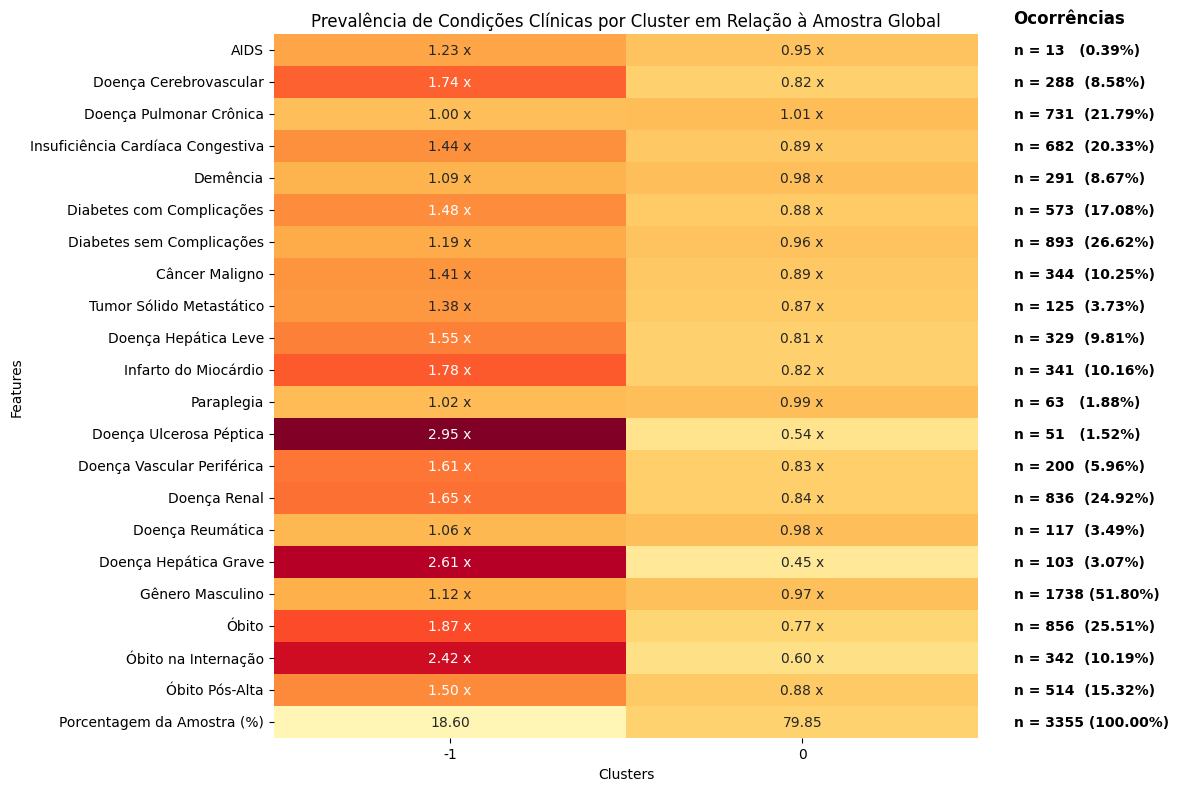

In [ ]:
helper.heatmapClustersCategorical(
    figsize=FIGSIZE_CLUSTER_HEATMAP,
    relativeTotal=True,
    savepath=IMAGES_SAVE_PATH + "dbscan-ae-categorical-relative"
)

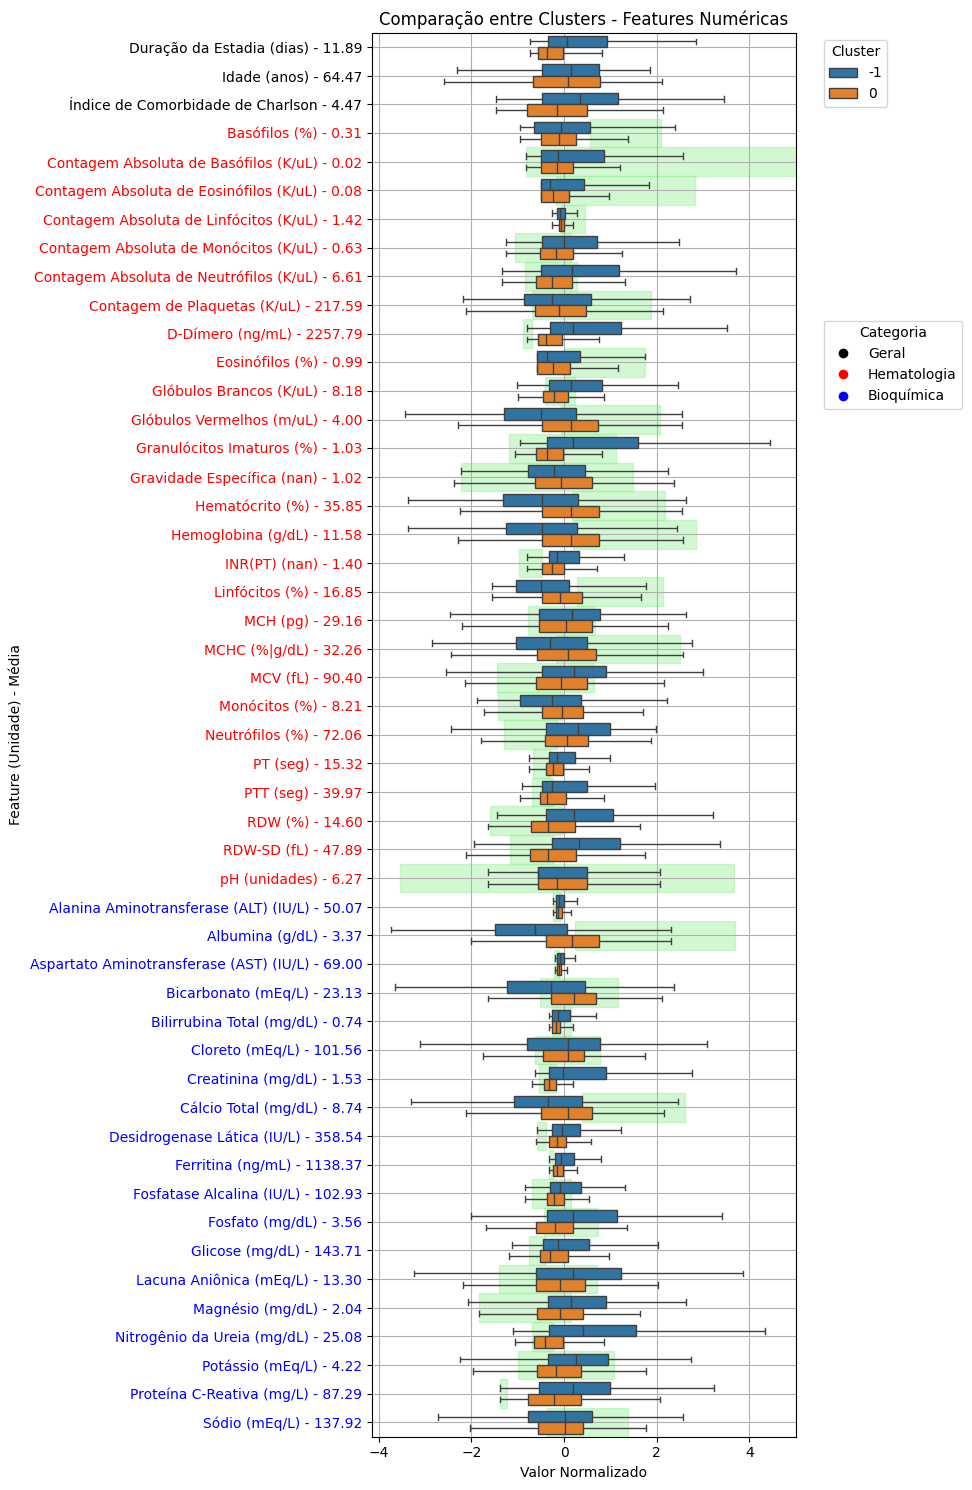

[]

In [ ]:
helper.showClusterCompareNumerical(
    scaled="standard",
    topFeatures=-1,
    max_features=-1,
    figsize=(10, 15),
    byVariance=False,
    # savepath=IMAGES_SAVE_PATH + "dbscan-ae-numerical"
)

In [ ]:
selectedClusters = [-1, 0]

In [ ]:
helper.setClusteredAutoencoder()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:24<00:00,  4.02it/s]


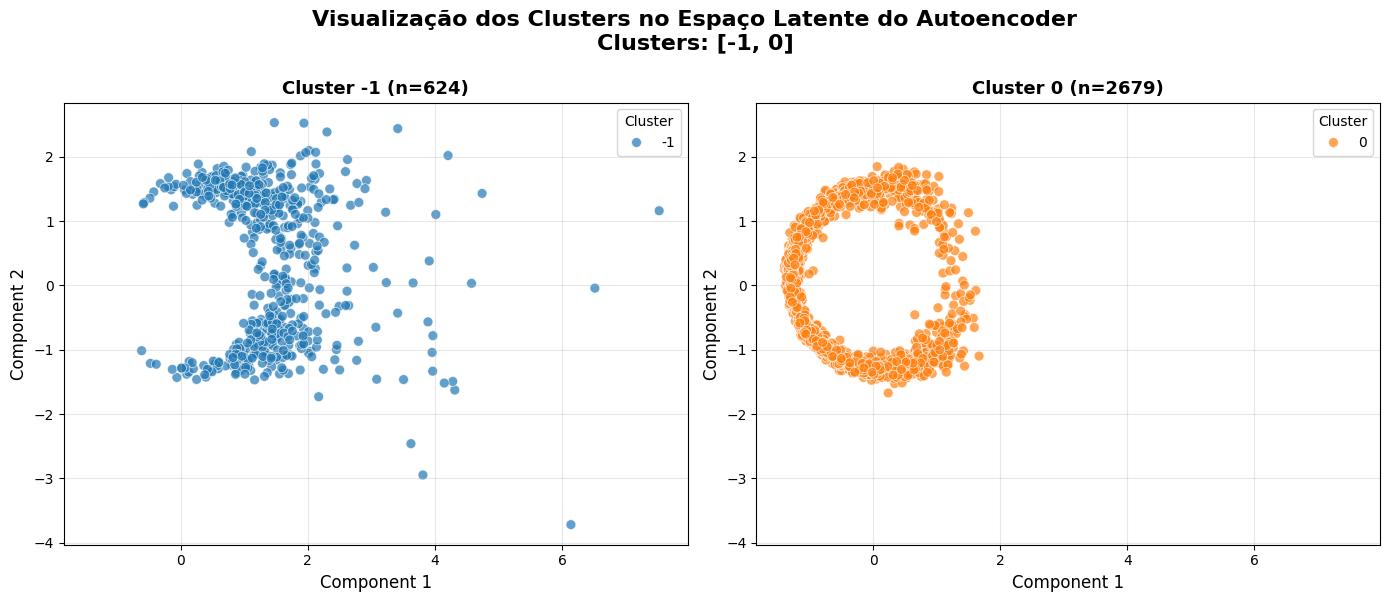

In [ ]:
helper.showClusteredAutoencoder(selectedClusters=selectedClusters, savepath=IMAGES_SAVE_PATH + "dbscan-ae-autoencoder")

##### Future data


2026-01-28 13:20:34,045 - Modules.FutureAnalysisModule - WARNING - 84 subject_ids in target data are missing from reference data. These will be filtered out.
2026-01-28 13:20:34,049 - Modules.FutureAnalysisModule - WARNING - 551 subject_ids in target data are missing from reference data. These will be filtered out.
2026-01-28 13:20:34,065 - Modules.FutureAnalysisModule - INFO - Clusters inserted for 3649 records
2026-01-28 13:20:34,075 - Modules.FutureAnalysisModule - INFO - Auto-detected 19 binary features for analysis
2026-01-28 13:20:34,102 - Modules.FutureAnalysisModule - INFO - Delta clusters calculated for 1 clusters
2026-01-28 13:20:34,104 - Modules.FutureAnalysisModule - INFO - FutureAnalysisHelper initialized with 3355 past records and 2257 future records
2026-01-28 13:20:34,108 - Modules.FutureAnalysisModule - INFO - Clusters inserted for 976 records
2026-01-28 13:20:34,112 - Modules.FutureAnalysisModule - INFO - Auto-detected 20 binary features for analysis
2026-01-28 13:20:

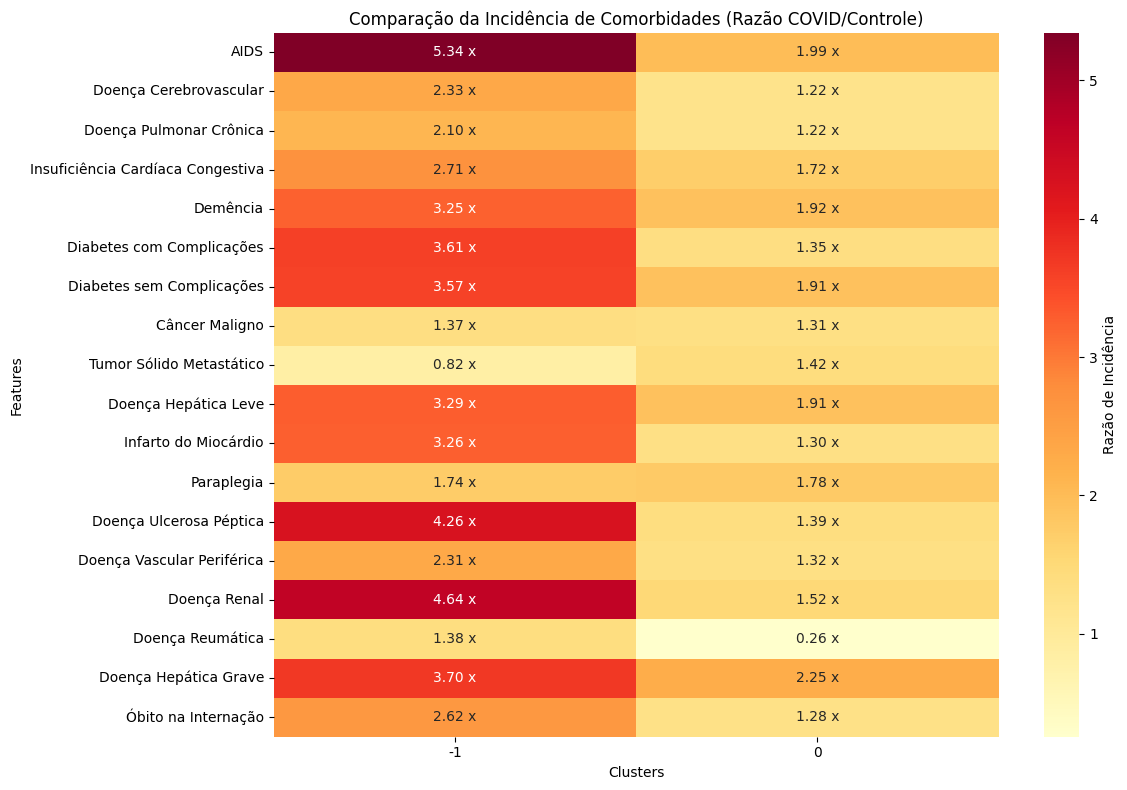

In [ ]:
future_helper = fa.FutureAnalysisHelper(
    helper.clusteredData, future_data, control, control_readmission
)
delta = future_helper.get_delta_clusters(percentage=True, relative_total=True)
future_helper.show_delta_heatmap(
    figsize=FIGSIZE_FUTURE_HEATMAP,
    relative_total=True,
    selected_clusters=selectedClusters,
    savepath=IMAGES_SAVE_PATH + "dbscan-ae-future",
)

In [ ]:
future_helper.get_mean_readmission()

2026-01-28 13:20:34,513 - Modules.FutureAnalysisModule - INFO - Clusters inserted for 2257 records
2026-01-28 13:20:34,535 - Modules.FutureAnalysisModule - INFO - Calculated mean readmission for 3 clusters


{'Mean readmission Cluster -1': np.float64(2.44),
 'Mean readmission Cluster 0': np.float64(2.27),
 'Mean readmission Cluster 1': np.float64(2.73),
 'Overall Mean readmission': 2.31}

In [ ]:
future_helper.get_mean_days_gap()

2026-01-28 13:20:34,569 - Modules.FutureAnalysisModule - INFO - Clusters inserted for 976 records
2026-01-28 13:20:34,571 - Modules.FutureAnalysisModule - INFO - Calculated mean days gap for 3 clusters


{'Mean days gap Cluster -1': np.float64(118.99),
 'Mean days gap Cluster 0': np.float64(130.29),
 'Mean days gap Cluster 1': np.float64(82.76),
 'Overall Mean days gap': 127.49}

In [ ]:
future_helper.get_mortality_rates(only_first_admission=True)

2026-01-28 13:20:34,583 - Modules.FutureAnalysisModule - INFO - Clusters inserted for 976 records
2026-01-28 13:20:34,586 - Modules.FutureAnalysisModule - INFO - Calculated mortality rates for 3 clusters


{'Mortality rate Cluster -1': 0.05,
 'Mortality rate Cluster 0': 0.13,
 'Mortality rate Cluster 1': 0.04,
 'Overall Mortality rate': 0.09}